# Dataset Description
## Monetary Policy Rate over the years
**Source**: Banco de la republica

**Download**: [link](https://suameca.banrep.gov.co/estadisticas-economicas/tablasPreconstruidas)

# Code
## Imports

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
from highlight_text import fig_text
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from pathlib import Path

pd.set_option("display.float_format", lambda x: "%.2f" % x)

BASE_DIR = Path.cwd().parent.parent

## Load data

In [98]:
path = "./data/tasa_monetaria.csv"
logo_path = BASE_DIR / "logo/logo.png"

df = pd.read_csv(path, encoding="utf-8")
logo = plt.imread(logo_path)

## Clean Data

In [99]:
df["Fecha"] = pd.to_datetime(df["Fecha"], dayfirst=True)
df_f = df[df["Fecha"].dt.year >= 2003]

years = df_f["Fecha"].dt.year.unique()
groups = (df_f["Fecha"].dt.year - df_f["Fecha"].dt.year.min()) // 4

avg = df_f.groupby(groups).mean()
avg.drop(columns=["Fecha"], inplace=True)
avg.index = ["Uribe 1", "Uribe 2", "Santos 1", "Santos 2", "Duque", "Petro"]
avg = avg.sort_values(by="Tasa (%)", ascending=True)

## Plot

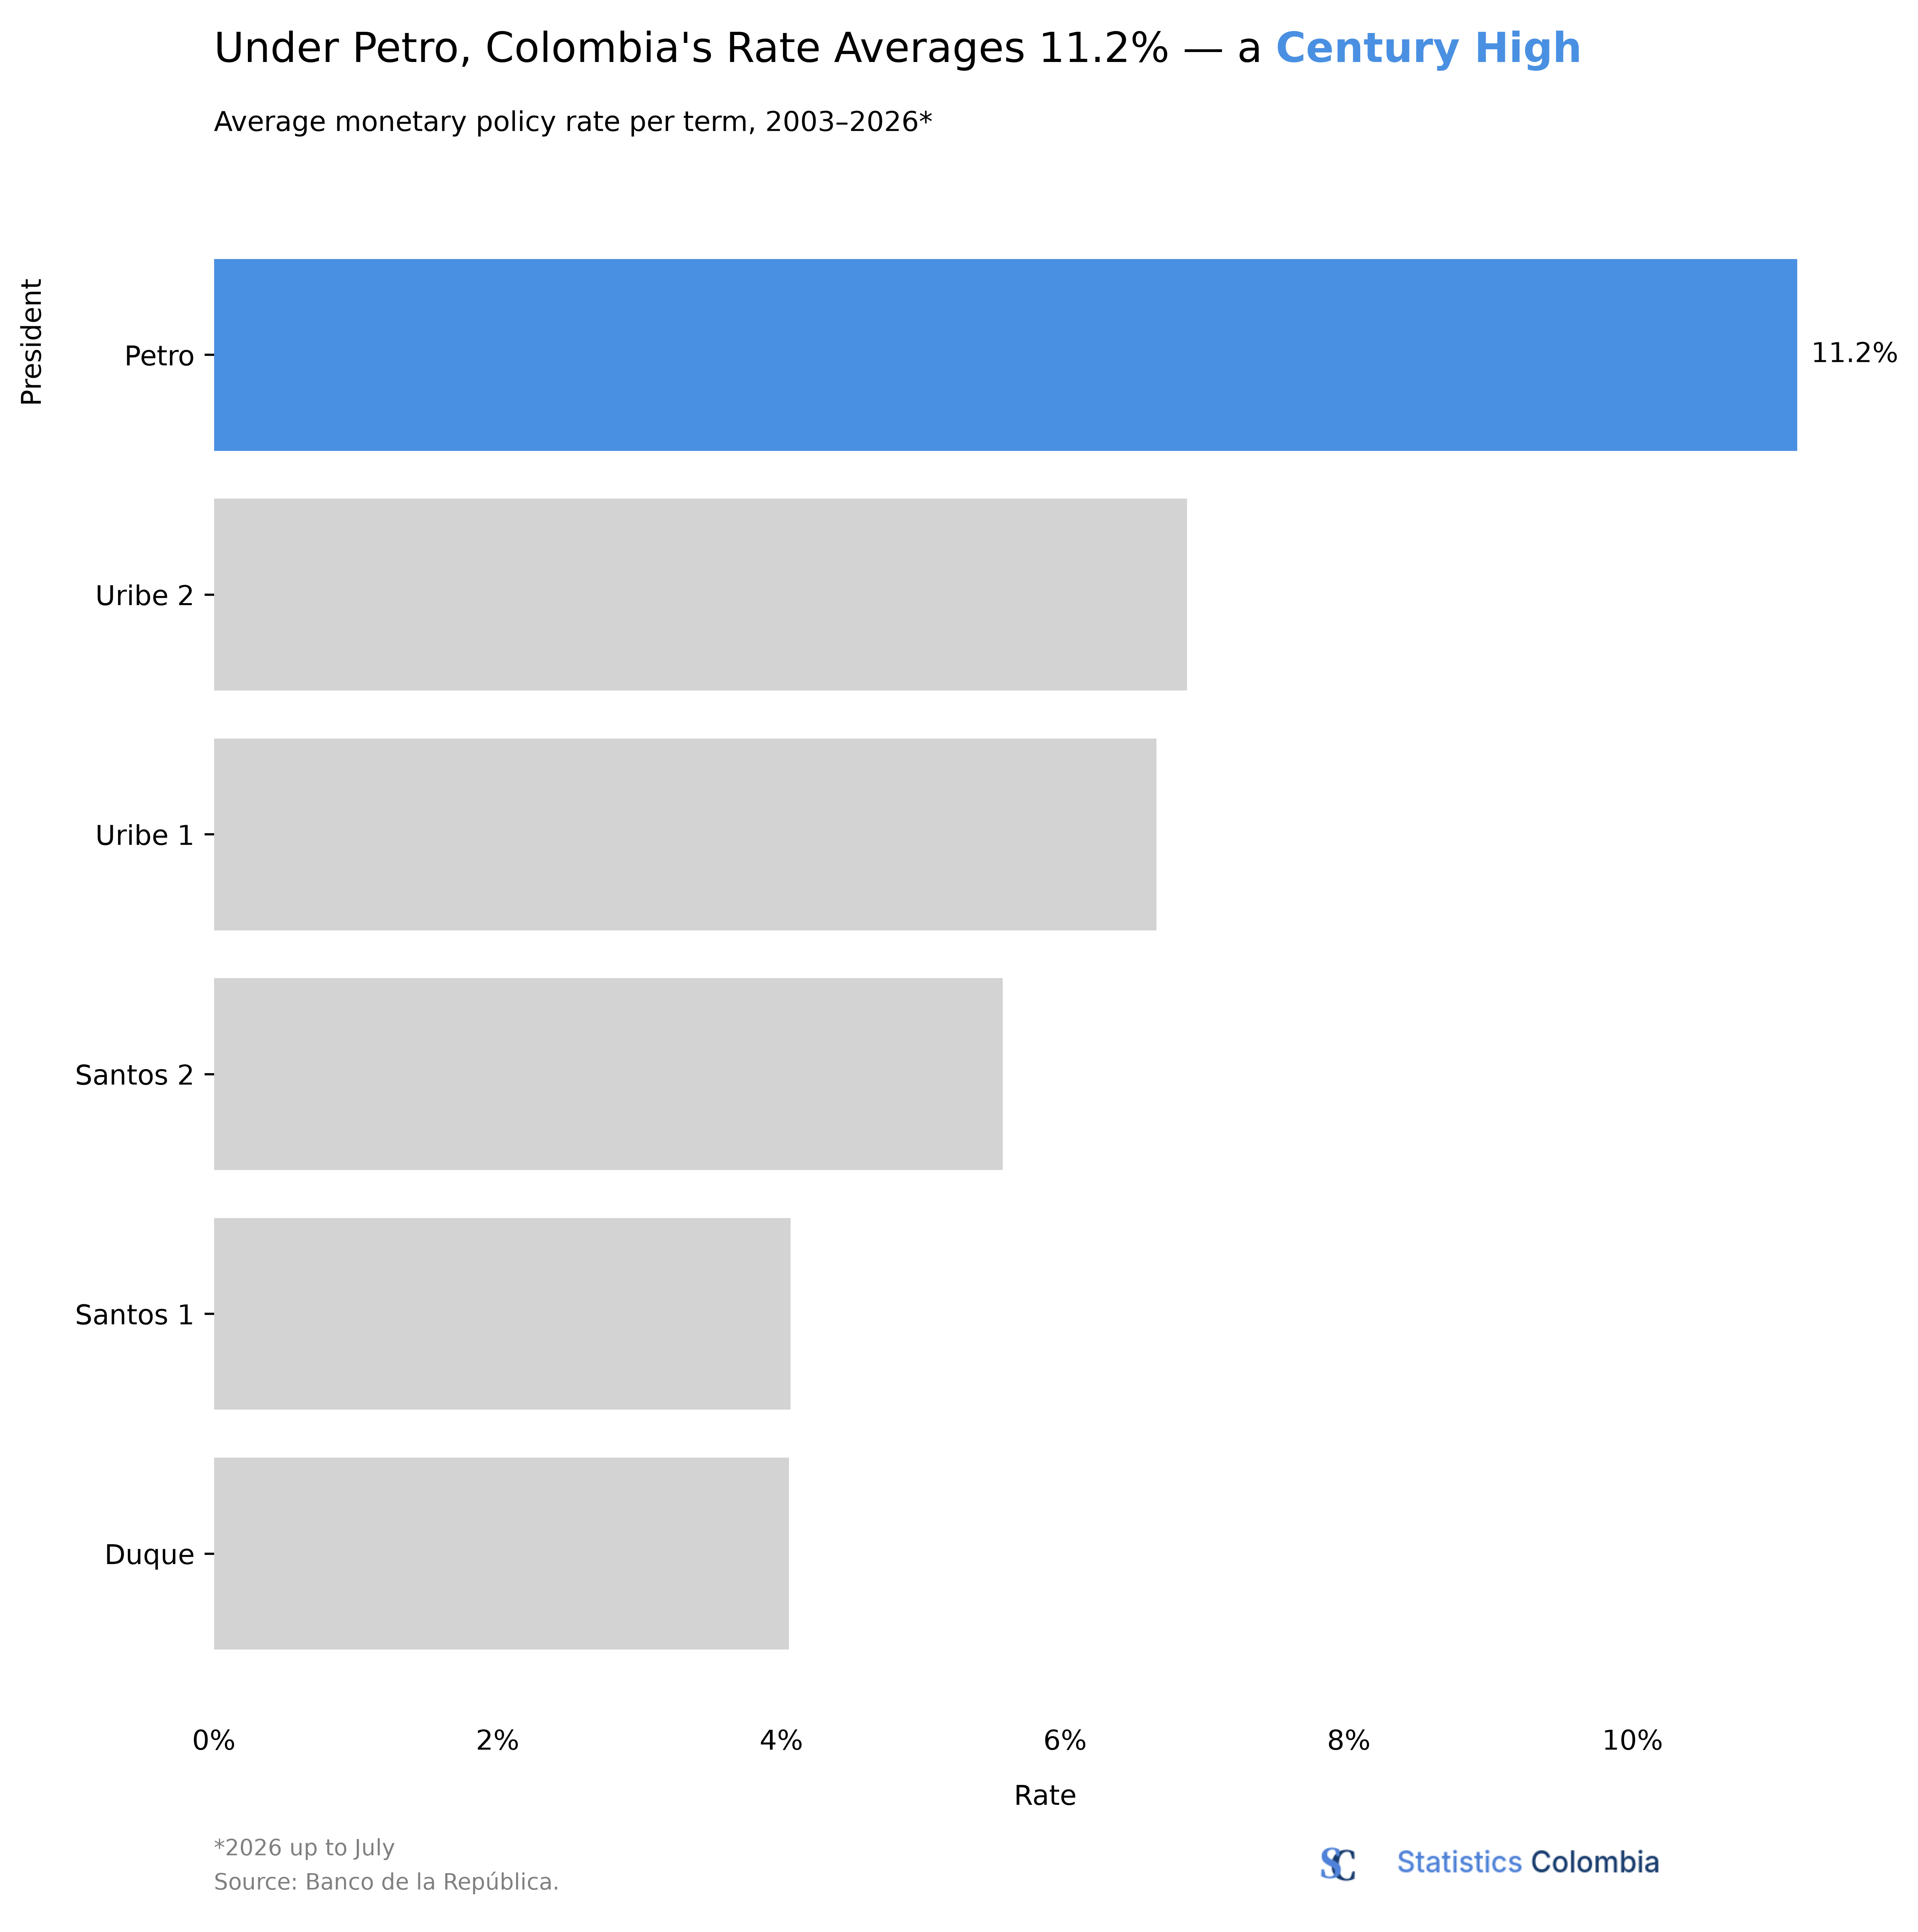

In [100]:
gray = "#D3D3D3"
blue = "#4a90e2"
colors = [blue if val == "Petro" else gray for val in avg.index]

plt.figure(figsize=(10.8, 10), dpi=500)

bars = plt.barh(avg.index, avg["Tasa (%)"], color=colors)

labels = ["%.1f%%" % avg.loc[v, "Tasa (%)"] if v == "Petro" else "" for v in avg.index]
plt.bar_label(bars, labels=labels, padding=5)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

plt.tick_params(axis="x", length=0)

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.xlabel("Rate", labelpad=10, fontsize=10)
plt.ylabel("President", y=0.9, labelpad=10, fontsize=10)

fig_text(
    0.125, 0.96,
    s="Under Petro, Colombia's Rate Averages 11.2% — a <Century High>",
    highlight_textprops=[{"color": blue, "weight": "bold"}],
    fontsize=15
)

fig_text(
    0.125, 0.92,
    s="Average monetary policy rate per term, 2003–2026*",
    fontsize=10
)

fig_text(
    0.125, 0.05,
    "*2026 up to July\n"
    "Source: Banco de la República.", 
    fontsize=8, color="gray",
)

imagebox = OffsetImage(logo, zoom=0.4)

ab = AnnotationBbox(imagebox, xy=(0.7, 0.035), xycoords="figure fraction",
                    frameon=False, pad=0)

plt.gca().add_artist(ab)

plt.show()